1. Install Library

In [ ]:
!pip install pandas numpy scikit-learn nltk sastrawi wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.6 MB/s eta 0:00:00


2. Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('stopwords')
# Ensure all necessary libraries are imported and available.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

3. Load Dataset

4. Loading Additional Datasets

In [ ]:
import pandas as pd

# Load kedua file
df_mbg = pd.read_csv('mbg_labeled.csv')
df_final = pd.read_csv('mbg_labeled.csv')

# Cek info (opsional)
print("mbg_labeled.csv Info:")
df_mbg.info()

print("\nmbg_labeled.csv Info:")
df_final.info()

# Gabungkan (append ke bawah)
df_combined = pd.concat([df_mbg, df_final], ignore_index=True)

# Hapus duplikat (penting untuk data tweet)
df_combined = df_combined.drop_duplicates()

# Reset index
df_combined.reset_index(drop=True, inplace=True)

# Simpan hasil gabungan
df_combined.to_csv('mbg_combined.csv', index=False)

# Preview hasil
print("\nCombined Data:")
display(df_combined.head())
print("\nTotal data:", len(df_combined))

mbg_labeled.csv Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   query      199 non-null    object
 1   tab        199 non-null    object
 2   tweet      199 non-null    object
 3   sentiment  199 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.3+ KB

mbg_labeled.csv Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   query      199 non-null    object
 1   tab        199 non-null    object
 2   tweet      199 non-null    object
 3   sentiment  199 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.3+ KB

Combined Data:


,query,tab,tweet,sentiment
0,MBG,top,MBG ini sebenarnya alat kampanye wowo \r\n@pra...,0
1,MBG,top,Bangsa Indonesia berduka atas gugurnya tiga pr...,0
2,MBG,top,Kasus dugaan keracunan makanan program Makan B...,0
3,MBG,top,Pemandangan memprihatinkan ditemukan dalam pel...,0
4,MBG,top,-Anggaran 1 porsi MBG: 10rb (sad food)\r\n-Har...,0



Total data: 199


4. Data Cleaning

In [ ]:
import pandas as pd
import re

# Load hasil gabungan
df_combined = pd.read_csv('mbg_combined.csv')

# Fungsi cleaning
def clean_text(text):
    text = str(text)  # jaga-jaga kalau ada NaN
    text = text.lower()
    text = re.sub(r'http\S+', '', text)     # hapus URL
    text = re.sub(r'@\w+', '', text)        # hapus mention
    text = re.sub(r'#\w+', '', text)        # hapus hashtag
    text = re.sub(r'[^a-zA-Z\s]', '', text) # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip() # rapihin spasi
    return text

# Terapkan ke kolom tweet (biasanya 'text' atau 'full_text')
df_combined['clean_text'] = df_combined['tweet'].apply(clean_text)

# Hapus baris kosong setelah cleaning
df_combined = df_combined[df_combined['clean_text'] != '']

# Reset index
df_combined.reset_index(drop=True, inplace=True)

# Simpan hasil
df_combined.to_csv('mbg_cleaned.csv', index=False)

# Preview
print(df_combined[['tweet', 'clean_text']].head()) # Also changed 'text' to 'tweet' here for preview
print("\nTotal data setelah cleaning:", len(df_combined))

                                               tweet  \
0  MBG ini sebenarnya alat kampanye wowo \r\n@pra...   
1  Bangsa Indonesia berduka atas gugurnya tiga pr...   
2  Kasus dugaan keracunan makanan program Makan B...   
3  Pemandangan memprihatinkan ditemukan dalam pel...   
4  -Anggaran 1 porsi MBG: 10rb (sad food)\r\n-Har...   

                                          clean_text  
0  mbg ini sebenarnya alat kampanye wowo yg dibia...  
1  bangsa indonesia berduka atas gugurnya tiga pr...  
2  kasus dugaan keracunan makanan program makan b...  
3  pemandangan memprihatinkan ditemukan dalam pel...  
4  anggaran porsi mbg rb sad food harga chicken s...  

Total data setelah cleaning: 199


5. Stopword Removal + Stemming

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


# Load data hasil cleaning
df_combined = pd.read_csv('mbg_cleaned.csv')

# Stopwords Bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi preprocessing
def preprocess_text(text):
    text = str(text)
    words = text.split()

    # Stopword removal
    words = [word for word in words if word not in stop_words]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    return ' '.join(words)

# Terapkan ke kolom clean_text
df_combined['processed_text'] = df_combined['clean_text'].apply(preprocess_text)

# Hapus data kosong setelah preprocessing
df_combined = df_combined[df_combined['processed_text'] != '']

# Reset index
df_combined.reset_index(drop=True, inplace=True)

# Simpan hasil akhir
df_combined.to_csv('mbg_preprocessed.csv', index=False)

# Preview
print(df_combined[['clean_text', 'processed_text']].head())
print("\nTotal data setelah preprocessing:", len(df_combined))

                                          clean_text  \
0  mbg ini sebenarnya alat kampanye wowo yg dibia...   
1  bangsa indonesia berduka atas gugurnya tiga pr...   
2  kasus dugaan keracunan makanan program makan b...   
3  pemandangan memprihatinkan ditemukan dalam pel...   
4  anggaran porsi mbg rb sad food harga chicken s...   

                                      processed_text  
0  mbg alat kampanye wowo yg biaya rakyat pilpres...  
1  bangsa indonesia duka gugur prajurit tni tugas...  
2  duga racun makan program makan gizi gratis mbg...  
3  pandang prihatin temu laksana program makan gi...  
4  anggar porsi mbg rb sad food harga chicken ste...  

Total data setelah preprocessing: 199


6. TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF
tfidf = TfidfVectorizer()

# Gunakan kolom hasil preprocessing
X = tfidf.fit_transform(df_combined['processed_text'])

print("Shape TF-IDF:", X.shape)

Shape TF-IDF: (199, 1210)


7. Split Data Training & Testing

In [ ]:
y = df_combined['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8. Naive Bayes Model

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

9. Evaluasi Model

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.78      1.00      0.87        31
           2       0.00      0.00      0.00         9

    accuracy                           0.78        40
   macro avg       0.39      0.50      0.44        40
weighted avg       0.60      0.78      0.68        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


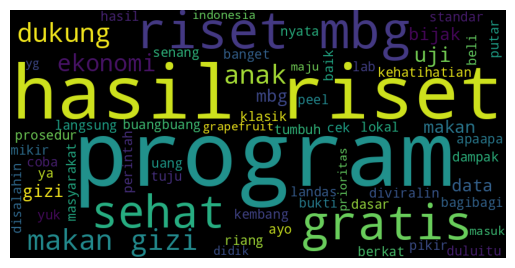

In [ ]:
positive_text = ' '.join(df_combined[df_combined['sentiment']==1]['processed_text'])

wordcloud = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

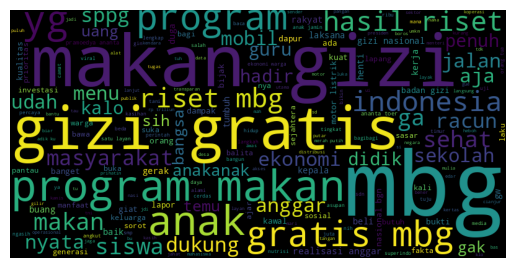

In [ ]:
negative_text = ' '.join(df_combined[df_combined['sentiment']==0]['processed_text'])

wordcloud = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

Grafik distribusi

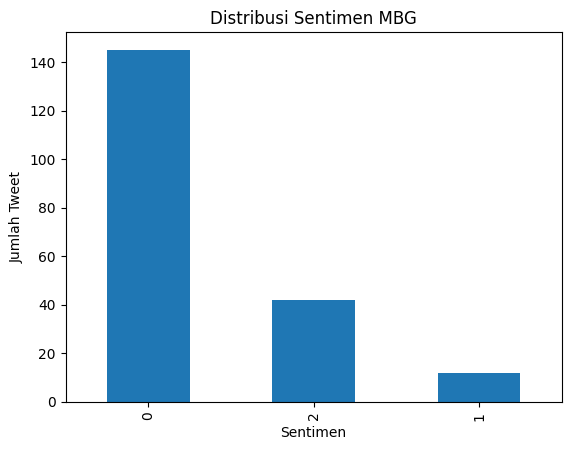

In [ ]:
df_combined['sentiment'].value_counts().plot(kind='bar')
plt.title('Distribusi Sentimen MBG')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Tweet')
plt.show()

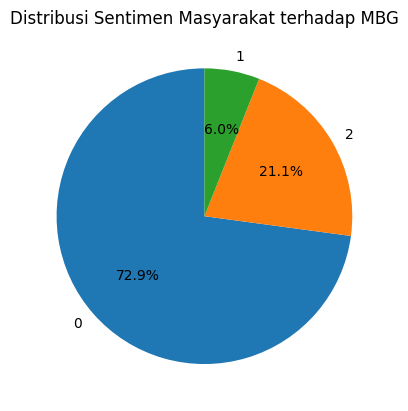

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df_combined['sentiment'].value_counts()

plt.figure()
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribusi Sentimen Masyarakat terhadap MBG')
plt.show()